# Tutorial: the `EchoStateNetwork` class

Introduction to the `EchoStateNetwork` class. The echo state network (ESN)
implementation is based on [Racca & Magri (2021)](https://doi.org/10.1016/j.neunet.2021.05.004):
ridge-regression training with chaotic recycle validation, and Bayesian
hyperparameter optimization.

In this tutorial we will use an `EchoStateNetwork` to model the Lorenz 63 system,
with full and partial observability of the state.
For ESNs conditioned on a physical parameter, see the
[parametric ESN tutorial](02_parametric_esn.ipynb).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from echostatenetwork import EchoStateNetwork

# help(EchoStateNetwork)

# Create training data from the Lorenz 63 model

$$
\dot{x} = \sigma (y - x), \qquad
\dot{y} = x (\rho - z) - y, \qquad
\dot{z} = x y - \beta z,
$$

with the classical parameters ($\sigma = 10$, $\rho = 28$, $\beta = 8/3$), for which
the system is chaotic with leading Lyapunov exponent $\lambda_1 \approx 0.906$.
We integrate the system, discard the transient onto the attractor, and add
measurement noise.

In [2]:
from scipy.integrate import solve_ivp


def lorenz63_dataset(num_lyap_times=300, dt=0.02, noise_level=0.02, seed=0,
                     rho=28., sigma=10., beta=8. / 3.):
    """Clean and noisy Lorenz 63 trajectories on the attractor."""
    t_lyap = 1 / 0.906                    # Lyapunov time of the Lorenz 63 system
    N_lyap = int(t_lyap / dt)             # number of dt steps per Lyapunov time
    t_transient = 10 * t_lyap             # discarded: initial condition -> attractor

    def rhs(t, u):
        x, y, z = u
        return [sigma * (y - x), x * (rho - z) - y, x * y - beta * z]

    t_eval = np.arange(0, t_transient + num_lyap_times * N_lyap * dt, dt)
    sol = solve_ivp(rhs, [0, t_eval[-1]], y0=[1., 1., 1.], t_eval=t_eval,
                    method='RK45', rtol=1e-9, atol=1e-12)

    clean_data = sol.y.T[t_eval > t_transient]
    t = sol.t[t_eval > t_transient] - t_transient

    rng = np.random.default_rng(seed)
    noisy_data = clean_data + noise_level * np.std(clean_data, axis=0) * rng.standard_normal(clean_data.shape)
    return dict(clean_data=clean_data, noisy_data=noisy_data, t=t, N_lyap=N_lyap)


dataset = lorenz63_dataset(noise_level=0.02, num_lyap_times=300)

clean_data = dataset['clean_data']
noisy_data = dataset['noisy_data']
t = dataset['t']
N_lyap = dataset['N_lyap']

### Separate data into train, validation and test datasets and visualize

In [3]:
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 60 * N_lyap - N_val
N_test = noisy_data.shape[0] - sum((N_train, N_val, N_transient))


train_val_data = noisy_data[N_transient:N_transient + N_train + 2 * N_val]

test_data = noisy_data[N_transient + N_train + N_val:N_transient + N_train + N_val + N_test]
test_data_clean = clean_data[N_transient + N_train + N_val:N_transient + N_train + N_val + N_test]  # Truth to compare the tests

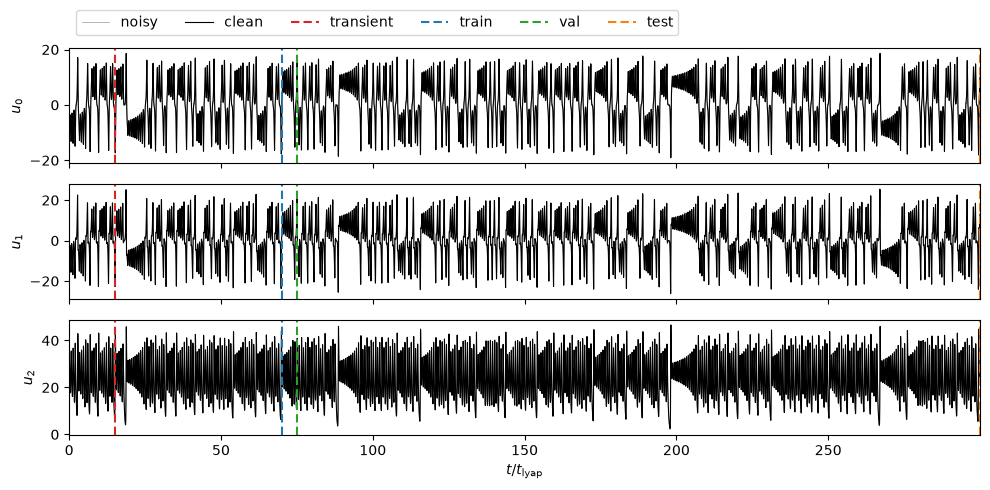

In [4]:
dt = t[1] - t[0]
t_lyap = N_lyap * dt


def plot_train_dataset(clean, noisy, t_scaled, t_transient, t_train, t_val, t_test):
    edges = np.cumsum([t_transient, t_train, t_val, t_test])
    fig, axs = plt.subplots(3, 1, sharex=True, figsize=(10, 5), layout='tight')
    for dim, ax in enumerate(axs):
        ax.plot(t_scaled, noisy[:, dim], c='0.6', lw=0.5, label='noisy')
        ax.plot(t_scaled, clean[:, dim], 'k', lw=0.8, label='clean')
        for edge, c, name in zip(edges, ['C3', 'C0', 'C2', 'C1'],
                                 ['transient', 'train', 'val', 'test']):
            ax.axvline(edge, c=c, dashes=[4, 2], label=name if dim == 0 else None)
        ax.set(ylabel=f'$u_{dim}$')
    axs[0].legend(ncols=6, loc='lower left', bbox_to_anchor=(0, 1.05))
    axs[-1].set(xlabel='$t / t_\\mathrm{lyap}$', xlim=(0, t_scaled[-1]))


split_times = [tt / N_lyap for tt in [N_transient, N_train, N_val, N_test]]

plot_train_dataset(clean_data, noisy_data, t / t_lyap, *split_times)

# Initialize the ESN
NB: Different initializations result in different Wout.

In [5]:
ESN_params = dict(N_wash=10,  # Number of washout steps i.e., open-loop initialization
                  N_units=50,  # Number of neurons
                  upsample=2,  # We want the ESN to predict t + upsample * dt
                  t_train=N_train * dt,  # Training time
                  t_val=N_val * dt,  # Validation time
                  t_test=2 * N_val * dt,  # Testing time
                  # Training-specific input_parameters
                  N_func_evals=30,
                  N_grid=5,
                  noise=1e-2,
                  Win_type='sparse',
                  N_folds=8,
                  N_split=5,
                  # Hyperparameter optimization ranges
                  rho_range=(.2, .95),
                  sigma_in_range=(-2, 2),
                  tikh_range=[1E-9, 1E-10],
                  #   random_initialization=True
                  )


# Initialize ESN class
ESN_init = EchoStateNetwork(y=np.zeros((3, 1)),
                            dt=dt,
                            **ESN_params)

# Train the ESN
The result of the ESN training is the output matrix. We can train the network to
input the full state or partial observations.

## a) Full observability

seed 0 	 Optimal hyperparameters: [np.float64(0.2), np.float64(1.0)], 1e-09, MSE: -0.9800969949409868

 ----------------- HYPERPARAMETER SEARCH ------------------
 5^2 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 


1	 2.000e-01	 1.000e-02	 1.000e-09	 -0.8040
2	 2.000e-01	 1.000e-01	 1.000e-10	 -0.7220


3	 2.000e-01	 1.000e+00	 1.000e-09	 -1.1223
4	 2.000e-01	 1.000e+01	 1.000e-09	 -0.8303


5	 2.000e-01	 1.000e+02	 1.000e-09	 -0.6501
6	 3.875e-01	 1.000e-02	 1.000e-10	 -0.8023


7	 3.875e-01	 1.000e-01	 1.000e-10	 -0.7666
8	 3.875e-01	 1.000e+00	 1.000e-10	 -1.0378


...

27	 2.707e-01	 5.788e-01	 1.000e-10	 -1.0567


28	 2.000e-01	 5.496e-01	 1.000e-10	 -1.0780


29	 2.119e-01	 8.484e-01	 1.000e-09	 -1.1361


30	 2.360e-01	 9.101e-01	 1.000e-09	 -1.1328


seed 252 	 Optimal hyperparameters: [0.21187356221530956, -0.07138247720841706], 1e-09, MSE: -1.1361225261197687


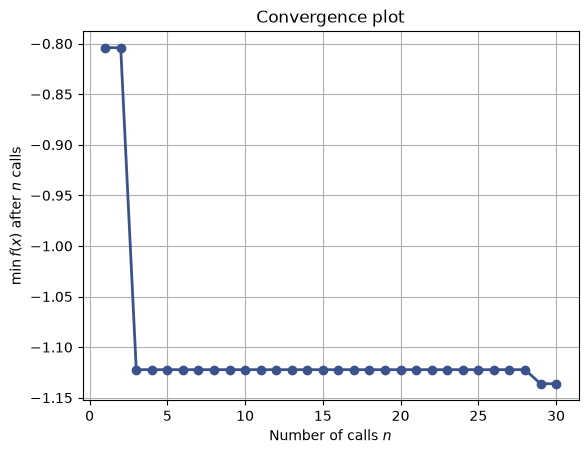

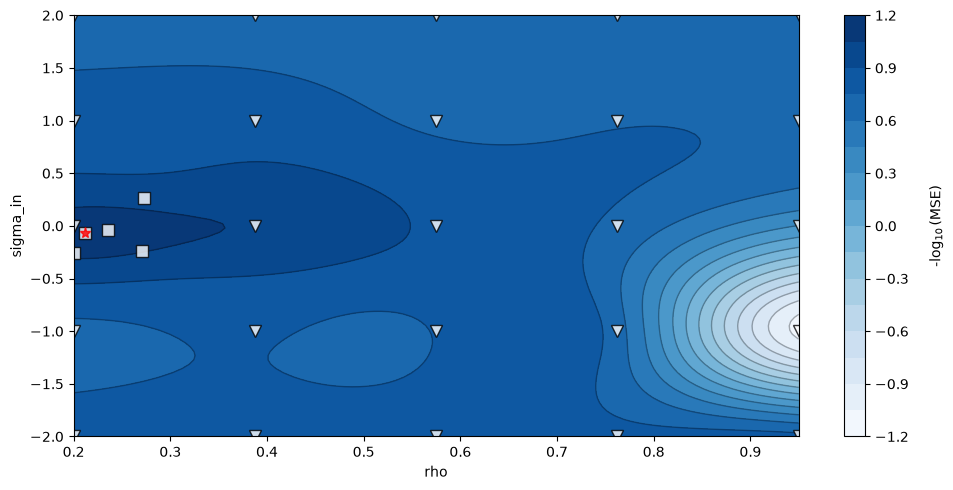

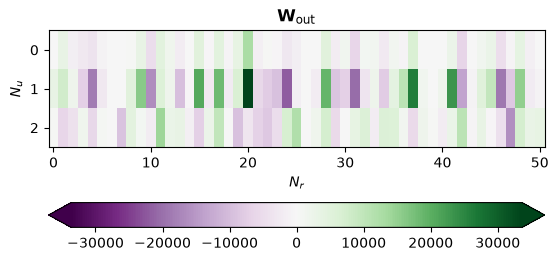

In [6]:
seeds = [0, 252]
for seed in seeds:
    ESN = ESN_init.copy()
    ESN.seed = seed  # seeds the W/Win generation
    ESN.train(train_val_data,
              add_noise=True,
              plot_training=seed == seeds[-1]
              )

## b) Partial observability


 ----------------- HYPERPARAMETER SEARCH ------------------
 5^2 grid and 5 points with Bayesian Optimization
		 rho	 sigma_in	 tikh	 MSE val 
1	 4.000e-01	 1.000e-02	 1.000e-09	 -0.7992


2	 4.000e-01	 1.000e-01	 1.000e-09	 -0.6726
3	 4.000e-01	 1.000e+00	 1.000e-10	 -0.9287


4	 4.000e-01	 1.000e+01	 1.000e-10	 -0.7148
5	 4.000e-01	 1.000e+02	 1.000e-09	 -0.6313


6	 5.375e-01	 1.000e-02	 1.000e-10	 -0.7991
7	 5.375e-01	 1.000e-01	 1.000e-09	 -0.6679


8	 5.375e-01	 1.000e+00	 1.000e-09	 -0.8250
9	 5.375e-01	 1.000e+01	 1.000e-10	 -0.7150


...

28	 8.752e-01	 2.798e+00	 1.000e-09	 -0.7478


29	 4.262e-01	 1.384e+00	 1.000e-09	 -0.9653


30	 4.493e-01	 1.558e+00	 1.000e-10	 -0.9409


seed 0 	 Optimal hyperparameters: [0.4262418183885689, 0.14104104843316012], 1e-09, MSE: -0.96526439792251
Running test for L= 0 

Overall tests min, max and mean MSE in 5 tests = -1.065, -1.065, -1.065.


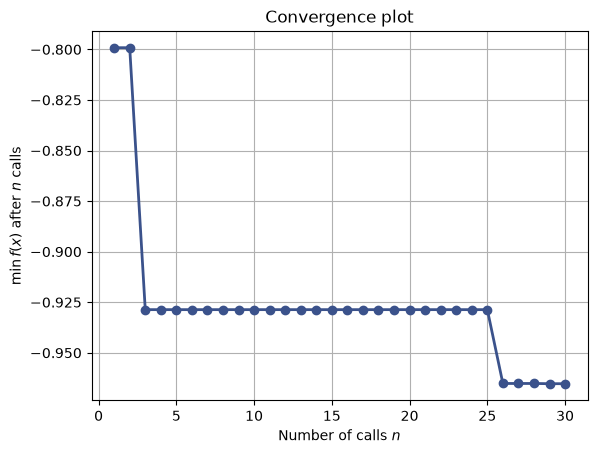

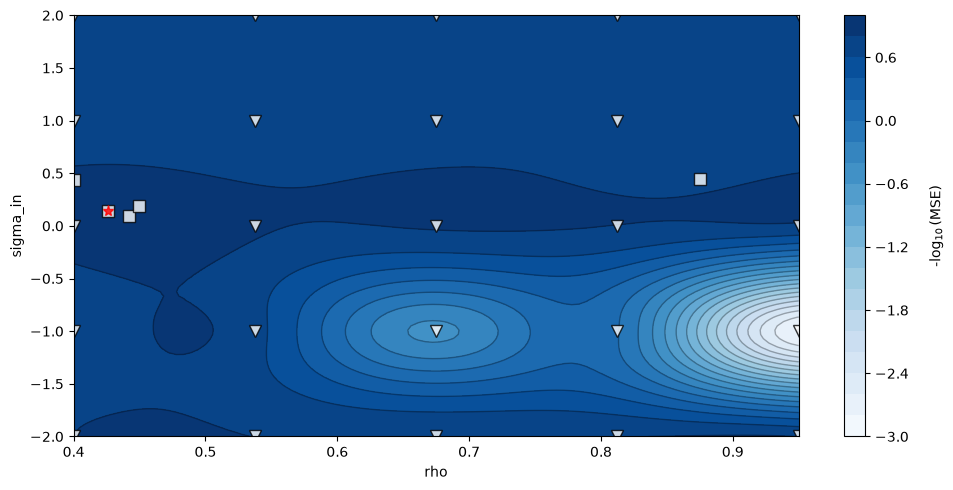

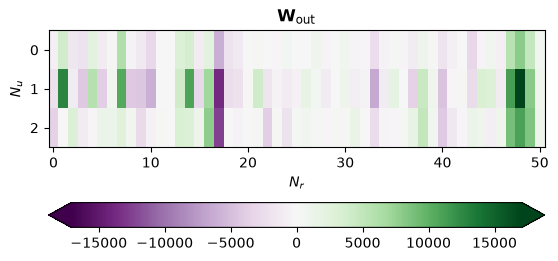

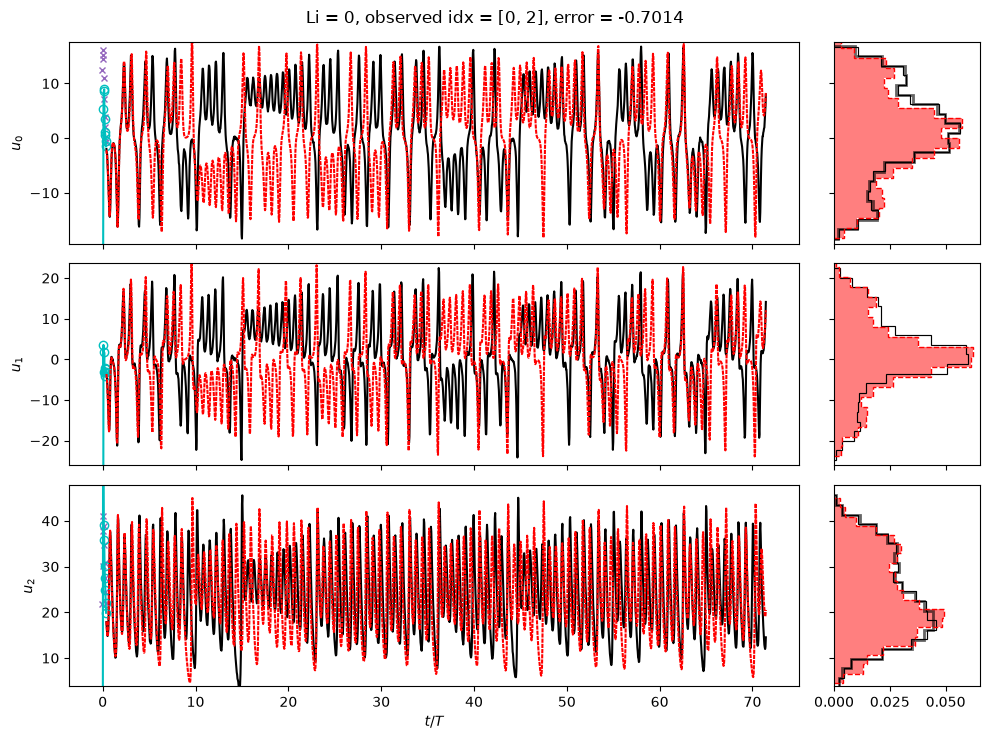

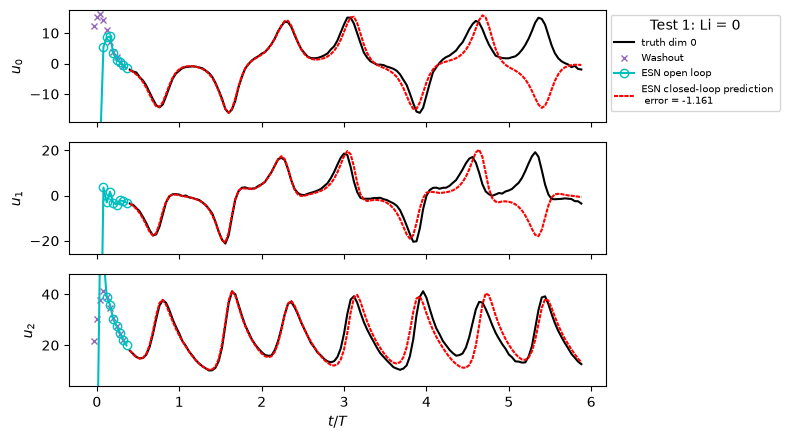

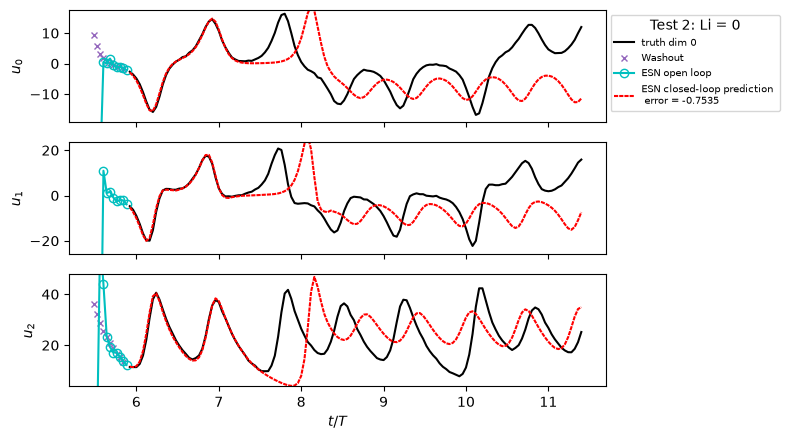

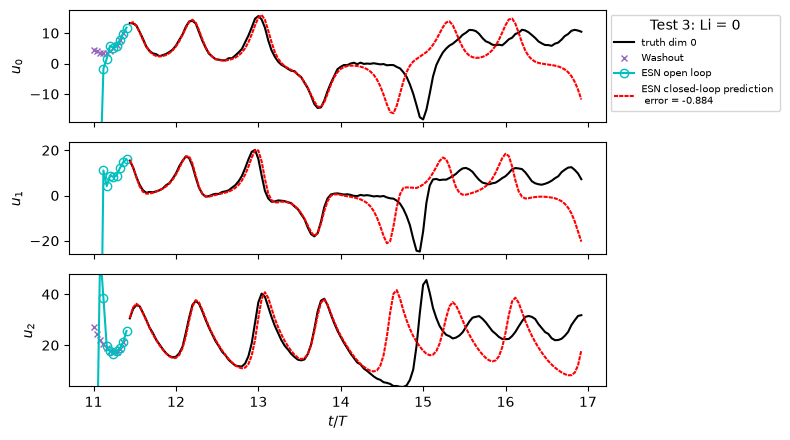

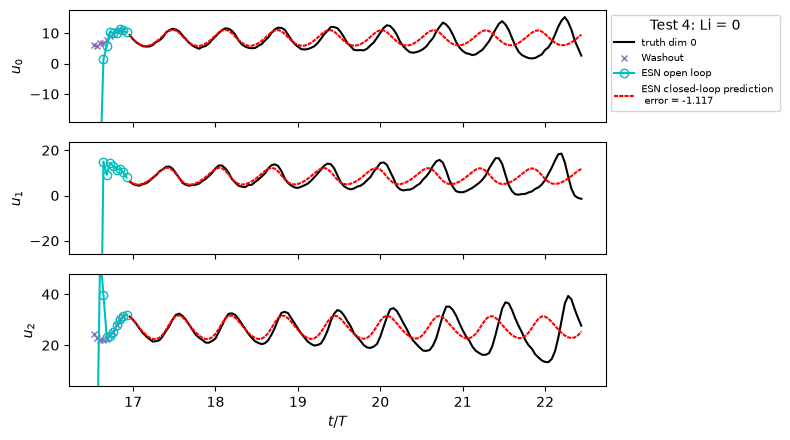

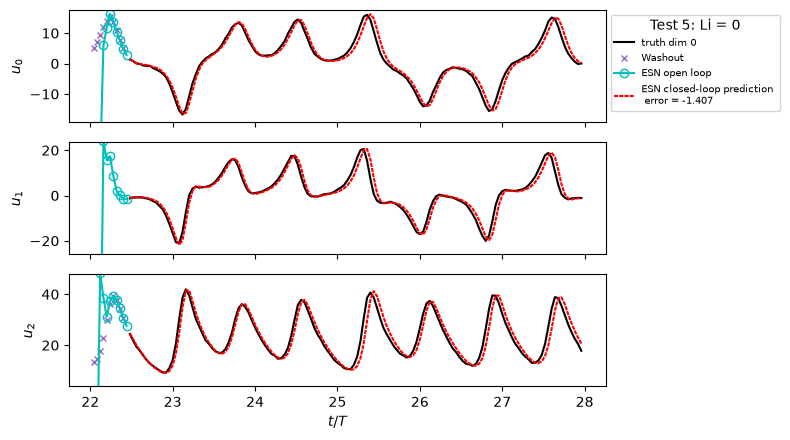

In [7]:
N_transient = 15 * N_lyap
N_val = 5 * N_lyap
N_train = 120 * N_lyap - N_val
N_test = noisy_data.shape[0] - sum((N_train, N_val, N_transient))

train_val_data = noisy_data[N_transient:N_transient + N_train + 2 * N_val]


# Define Echo state network input_parameters

ESN_partial = ESN_init.copy()
ESN_partial.N_folds = 12
ESN_partial.rho_range = (0.4, 0.95)

# Set the observed dimensions
ESN_partial.observed_idx = [0, 2]


ESN_partial.train(train_val_data,
                  add_noise=True,
                  plot_training=True,
                  )

If prediction is much worse, try increasing the length of the timeseries or number
of folds.